In [56]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.mgf_dataset import create_mgf_dataset
from src.model import SimpleTransformer
from src.mgf_dataset import simulate_ou_process

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load data

In [57]:
cfg = load_full_config()
model = SimpleTransformer(**cfg['architecture'])
model_path = os.path.join('..', cfg['paths']['save_dir'], 'model_mgf.pth')
device = torch.device("cuda" if torch.cuda.is_available() and cfg['system']['device'] == "cuda" else "cpu")


if os.path.exists(model_path):
    checkpoint = torch.load(model_path, map_location=device, weights_only=True)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print(f"Loaded model from {model_path}")
else:
    print(f"Model not found at {model_path}")
    print("Run: python ../scripts/train.py")

Loaded model from ../experiments/model_mgf.pth


In [58]:
cfg = load_full_config()
cfg

{'physics': {'theta': 0.15,
  'mu': 0.0,
  'sigma': 0.2,
  'dt': 0.1,
  'marginal_variance': 0.2,
  'kappa': 0.5},
 'theta_sampling': {'distribution': 'lognormal', 'mean': 0.0, 'sigma': 0.0},
 'structure': {'num_trajectories': 1000, 'sequence_length': 100},
 'target': {'order': 3},
 'training': {'train_split': 0.8, 'batch_size': 64},
 'paths': {'mgf_data_path': 'data/ou_mgf.pt',
  'save_dir': 'experiments',
  'mgf_model_name': 'model_mgf.pth'},
 'architecture': {'d_input': 1,
  'd_model': 20,
  'n_head': 1,
  'n_layers': 2,
  'max_len': 5000,
  'dim_feedforward': 64,
  'd_output': 3},
 'hyperparameters': {'batch_size': 64, 'learning_rate': 0.001, 'epochs': 200},
 'system': {'device': 'cpu'}}

In [59]:
trajectories, thetas, targets = create_mgf_dataset(cfg)
targets

tensor([[[ 0.0000,  0.0363,  0.0000],
         [ 0.5179,  0.0363,  0.0000],
         [ 0.4100,  0.0363,  0.0000],
         ...,
         [ 0.2920,  0.0363,  0.0000],
         [ 0.0057,  0.0363,  0.0000],
         [-0.2031,  0.0363,  0.0000]],

        [[ 0.0000,  0.0363,  0.0000],
         [-0.1739,  0.0363,  0.0000],
         [-0.1323,  0.0363,  0.0000],
         ...,
         [-0.0471,  0.0363,  0.0000],
         [-0.3493,  0.0363,  0.0000],
         [-0.5091,  0.0363,  0.0000]],

        [[ 0.0000,  0.0363,  0.0000],
         [ 0.1318,  0.0363,  0.0000],
         [ 0.0605,  0.0363,  0.0000],
         ...,
         [ 0.9116,  0.0363,  0.0000],
         [ 0.7388,  0.0363,  0.0000],
         [ 0.5030,  0.0363,  0.0000]],

        ...,

        [[ 0.0000,  0.0363,  0.0000],
         [ 0.1838,  0.0363,  0.0000],
         [ 0.1308,  0.0363,  0.0000],
         ...,
         [-0.2719,  0.0363,  0.0000],
         [-0.0882,  0.0363,  0.0000],
         [-0.2153,  0.0363,  0.0000]],

        [[

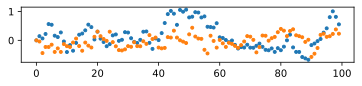

In [60]:

fig,ax = plt.subplots(figsize=(6,1))
ax.plot(trajectories[2,:,0].numpy(),".")
ax.plot(trajectories[300,:,0].numpy(),".")

In [61]:
trajectories[10,:,0].numpy()

array([ 0.        , -0.1470999 , -0.10071638,  0.3141568 ,  0.48695725,
        0.39385957,  0.411219  ,  0.3622123 ,  0.39989048,  0.13239416,
       -0.07688967, -0.02396744, -0.04891821, -0.18610838, -0.07858615,
       -0.19842765, -0.42014623, -0.8932887 , -0.86116314, -0.89195824,
       -0.58608174, -0.7288695 , -0.6313818 , -0.5263889 , -0.15158305,
        0.19370154, -0.00424846,  0.00995122, -0.16028965,  0.08526251,
        0.07418265,  0.4496031 ,  0.6891972 ,  0.71387106,  0.5070374 ,
        0.49759662,  0.17534426,  0.16537972,  0.16548392,  0.0980017 ,
        0.13533285,  0.2808106 ,  0.3002341 ,  0.10198505, -0.01895782,
       -0.1646665 , -0.09776132, -0.35963267, -0.19953737, -0.33341652,
       -0.05102864, -0.27709454, -0.17779645, -0.26298118, -0.3196379 ,
       -0.3454612 , -0.22696853, -0.27569857, -0.2471292 , -0.1735136 ,
       -0.16040501, -0.0938551 , -0.19623923, -0.20424902,  0.02809627,
        0.0159117 ,  0.10634043,  0.15807657, -0.04956023, -0.37

In [62]:
thetas.unsqueeze(1)

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
      

In [63]:
targets

tensor([[[ 0.0000,  0.0363,  0.0000],
         [ 0.5179,  0.0363,  0.0000],
         [ 0.4100,  0.0363,  0.0000],
         ...,
         [ 0.2920,  0.0363,  0.0000],
         [ 0.0057,  0.0363,  0.0000],
         [-0.2031,  0.0363,  0.0000]],

        [[ 0.0000,  0.0363,  0.0000],
         [-0.1739,  0.0363,  0.0000],
         [-0.1323,  0.0363,  0.0000],
         ...,
         [-0.0471,  0.0363,  0.0000],
         [-0.3493,  0.0363,  0.0000],
         [-0.5091,  0.0363,  0.0000]],

        [[ 0.0000,  0.0363,  0.0000],
         [ 0.1318,  0.0363,  0.0000],
         [ 0.0605,  0.0363,  0.0000],
         ...,
         [ 0.9116,  0.0363,  0.0000],
         [ 0.7388,  0.0363,  0.0000],
         [ 0.5030,  0.0363,  0.0000]],

        ...,

        [[ 0.0000,  0.0363,  0.0000],
         [ 0.1838,  0.0363,  0.0000],
         [ 0.1308,  0.0363,  0.0000],
         ...,
         [-0.2719,  0.0363,  0.0000],
         [-0.0882,  0.0363,  0.0000],
         [-0.2153,  0.0363,  0.0000]],

        [[

# Binary Switching OU Process

In [64]:
from src.mgf_dataset import simulate_binary_ou_process

# Parameters
num_traj = 5
seq_len = 500
theta = 1
mu = 5.0  # mean switches between +1 and -1
marginal_variance = 0.2
D = marginal_variance * theta
dt = 0.1
kappa = 0.5  # switching rate

theta_tensor = torch.full((num_traj,), theta)
D_tensor = torch.full((num_traj,), D)

trajectories_bin, states_bin = simulate_binary_ou_process(
    num_traj, seq_len, theta_tensor, mu, D_tensor, dt, kappa
)

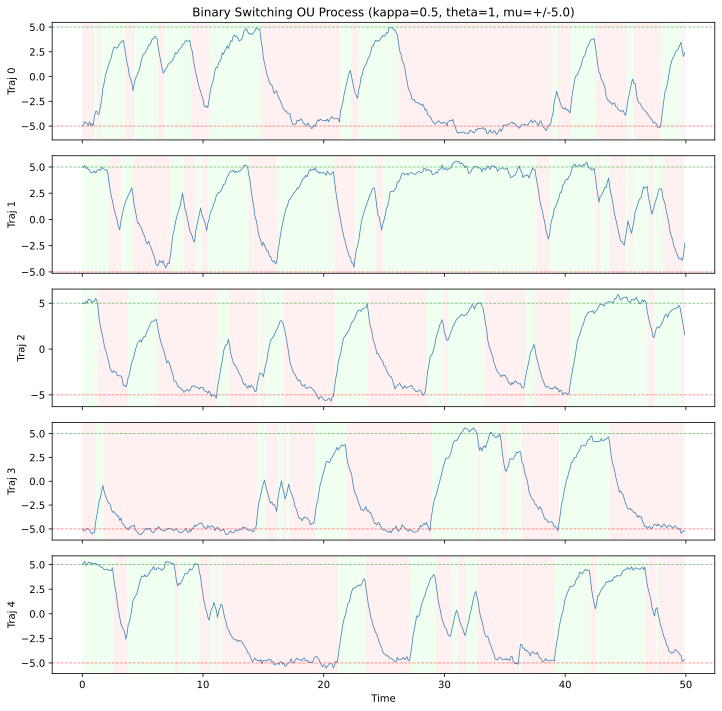

In [65]:
fig, axes = plt.subplots(num_traj, 1, figsize=(10, 2 * num_traj), sharex=True)
time = torch.arange(seq_len) * dt

for i in range(num_traj):
    ax = axes[i]
    traj = trajectories_bin[i, :, 0].numpy()
    state = states_bin[i, :].numpy()

    ax.plot(time.numpy(), traj, linewidth=0.8, color='steelblue')
    # Shade background by state
    for t_idx in range(seq_len - 1):
        color = '#ffcccc' if state[t_idx] < 0 else '#ccffcc'
        ax.axvspan(time[t_idx], time[t_idx + 1], alpha=0.3, color=color, linewidth=0)
    ax.axhline(mu, color='green', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.axhline(-mu, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_ylabel(f'Traj {i}')

axes[-1].set_xlabel('Time')
axes[0].set_title(f'Binary Switching OU Process (kappa={kappa}, theta={theta}, mu=+/-{mu})')
plt.tight_layout()

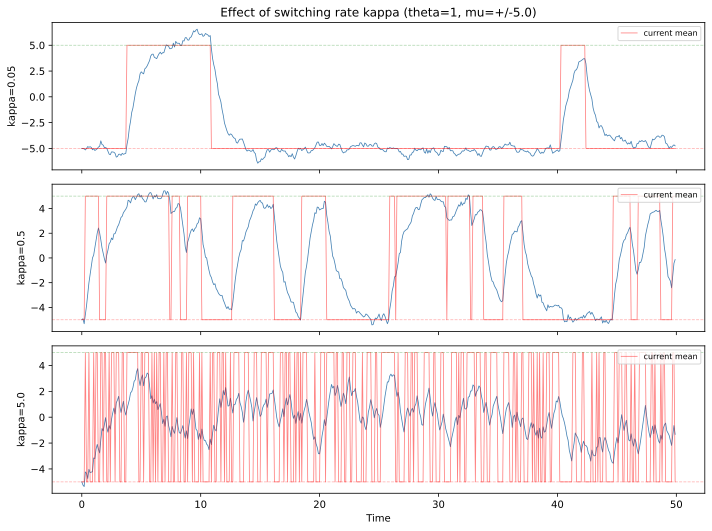

In [66]:
kappas = [0.05, 0.5, 5.0]
fig, axes = plt.subplots(len(kappas), 1, figsize=(10, 2.5 * len(kappas)), sharex=True)
time = torch.arange(seq_len) * dt

for j, k in enumerate(kappas):
    traj, st = simulate_binary_ou_process(1, seq_len, theta_tensor[:1], mu, D_tensor[:1], dt, k)
    ax = axes[j]
    ax.plot(time.numpy(), traj[0, :, 0].numpy(), linewidth=0.8, color='steelblue')
    ax.plot(time.numpy(), st[0, :].numpy() * mu, linewidth=0.8, color='red', alpha=0.5, label='current mean')
    ax.axhline(mu, color='green', linestyle='--', alpha=0.3, linewidth=0.8)
    ax.axhline(-mu, color='red', linestyle='--', alpha=0.3, linewidth=0.8)
    ax.set_ylabel(f'kappa={k}')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time')
axes[0].set_title(f'Effect of switching rate kappa (theta={theta}, mu=+/-{mu})')
plt.tight_layout()